In [1]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving IMDB Dataset.csv to IMDB Dataset.csv
User uploaded file "IMDB Dataset.csv" with length 66212309 bytes


In [2]:
# STEP 1: Install required libraries
!pip install -q xgboost
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

# Optional: Apply stemming
stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['cleaned_review'] = df['cleaned_review'].apply(stem_text)

# Encode sentiment labels (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Train-test split
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!")

✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!


In [7]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

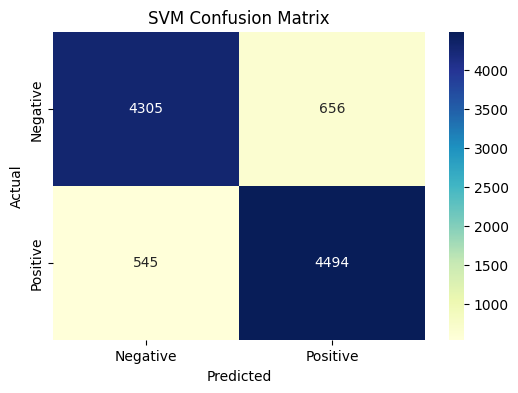

In [9]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib
import seaborn as sns # Import seaborn for enhanced visualizations




cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

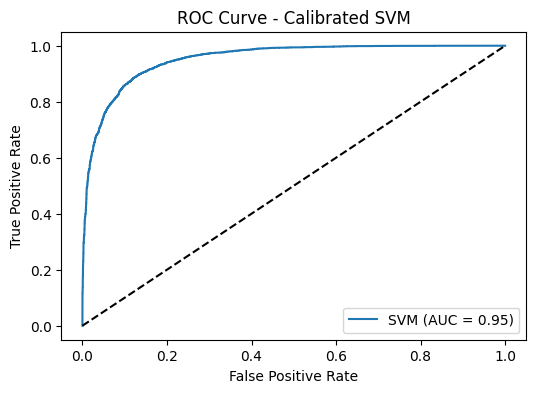

In [10]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, auc

calibrated_svm = CalibratedClassifierCV(svm_model)
calibrated_svm.fit(X_train_tfidf, y_train)
y_probs = calibrated_svm.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Calibrated SVM')
plt.legend()
plt.show()


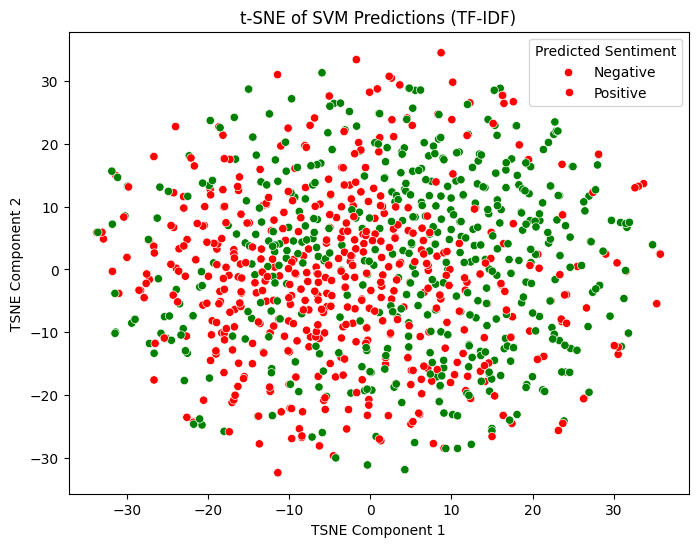

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_embedded = tsne.fit_transform(X_test_tfidf[:1000].toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_pred_svm[:1000], palette=['red', 'green'])
plt.title('t-SNE of SVM Predictions (TF-IDF)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend(title='Predicted Sentiment', labels=['Negative', 'Positive'])
plt.show()


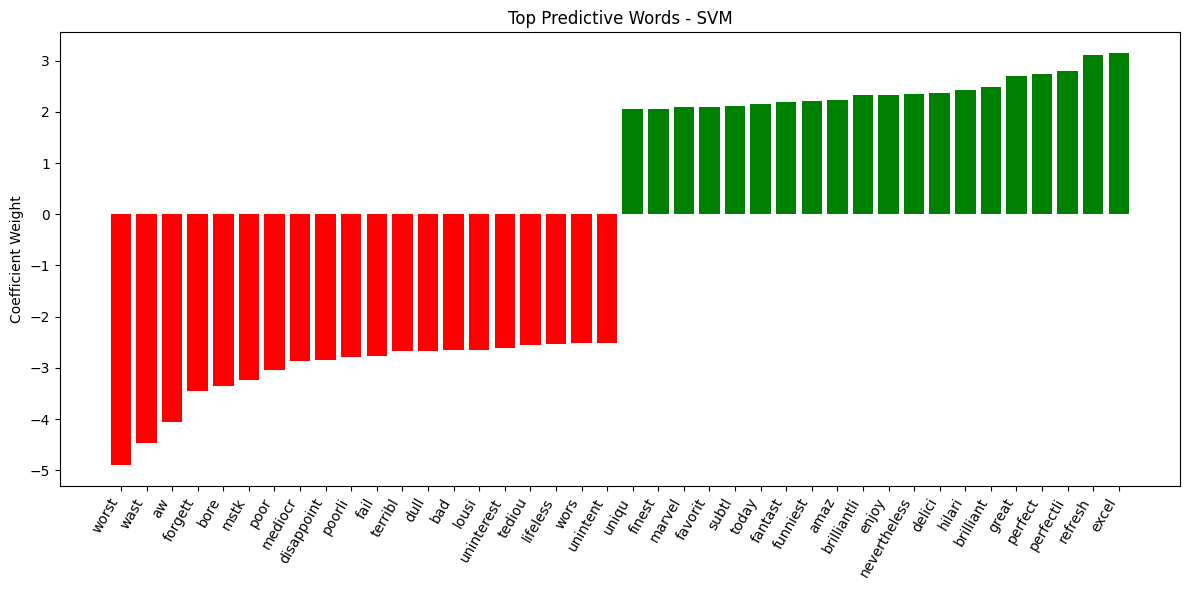

In [13]:
import numpy as np

# Replace 'tfidf' with 'tfidf_vectorizer'
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]

top_pos = np.argsort(coefficients)[-20:]
top_neg = np.argsort(coefficients)[:20]
top_words = np.hstack([top_neg, top_pos])
colors = ['red']*20 + ['green']*20

plt.figure(figsize=(12,6))
plt.bar(np.arange(40), coefficients[top_words], color=colors)
plt.xticks(np.arange(40), feature_names[top_words], rotation=60, ha='right')
plt.title("Top Predictive Words - SVM")
plt.ylabel("Coefficient Weight")
plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.manifold import TSNE

# === Step 1: Accuracy and Classification Report ===
print("✅ Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_svm))


✅ Accuracy: 0.8799

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



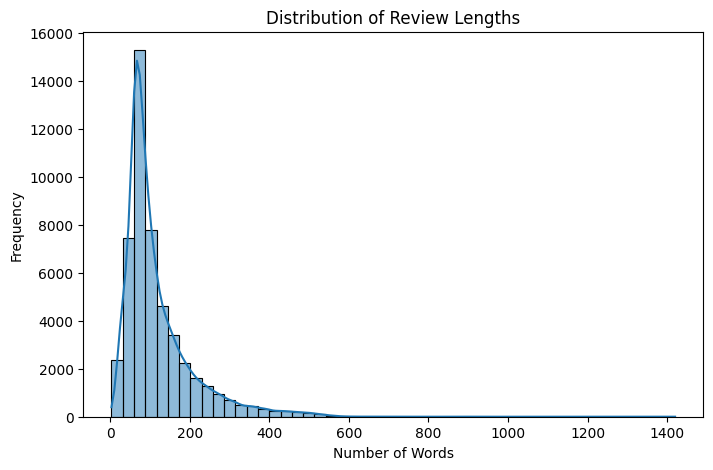

In [16]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
